In [ ]:
# ===========================================================
# STEP 1: Install libraries and import modules
# ===========================================================

import os, json, random, gc
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

# Colab installs
!pip -q install albumentations pydot keras-tuner

# TensorFlow install if missing
try:
    import tensorflow as tf
    print("✅ TensorFlow:", tf.__version__)
except ModuleNotFoundError:
    !pip -q install "tensorflow==2.15.0"
    import tensorflow as tf
    print("✅ TensorFlow installed:", tf.__version__)

from tensorflow.keras import layers, Model, Input, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from keras_tuner import HyperModel
from keras_tuner.tuners import RandomSearch

# Optional: reduce TF memory pre-allocation on GPU
tf.keras.backend.clear_session()
gc.collect()

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU memory growth enabled")
    except Exception as e:
        print("⚠️ Could not set memory growth:", e)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.2 MB/s eta 0:00:00
✅ TensorFlow: 2.19.0
✅ GPU memory growth enabled


In [ ]:
# ===========================================================
# STEP 2: Mount Drive + define paths (WD only)
# ===========================================================

from google.colab import drive
drive.mount("/content/drive")

data_path = "/content/drive/MyDrive/Colab Notebooks/Dataset_BUSI_with_GT"

save_root = "/content/drive/MyDrive/Colab Notebooks/BUSI_WD_ONLY"
os.makedirs(save_root, exist_ok=True)

dataset_dir = os.path.join(save_root, "dataset_csvs")
splits_dir  = os.path.join(save_root, "splits")
models_dir  = os.path.join(save_root, "models")
tuner_dir   = os.path.join(save_root, "tuner")

for d in [dataset_dir, splits_dir, models_dir, tuner_dir]:
    os.makedirs(d, exist_ok=True)

classes = ["normal", "benign", "malignant"]
image_ext = (".png", ".jpg", ".jpeg")

print("data_path :", data_path)
print("save_root :", save_root)
print("models_dir:", models_dir)


Mounted at /content/drive
data_path : /content/drive/MyDrive/Colab Notebooks/Dataset_BUSI_with_GT
save_root : /content/drive/MyDrive/Colab Notebooks/BUSI_WD_ONLY
models_dir: /content/drive/MyDrive/Colab Notebooks/BUSI_WD_ONLY/models


In [ ]:
# ===========================================================
# STEP 3: Build WD CSV directly from folders (no WOD/WODA)
# WD = all original images (includes duplicates), exclude *_mask and *_aug*
# ===========================================================

def list_wd_images(data_path, classes, image_ext):
    rows = []
    for cls in classes:
        folder = os.path.join(data_path, cls)
        if not os.path.isdir(folder):
            print(f"⚠️ Missing folder: {folder}")
            continue

        for f in sorted(os.listdir(folder)):
            lf = f.lower()

            # keep only image files
            if not lf.endswith(image_ext):
                continue

            # exclude masks and any augmented files
            if "_mask" in lf:
                continue
            if "_aug" in lf:
                continue

            full_path = os.path.join(folder, f)
            rows.append({"class": cls, "file": f, "path": full_path})
    return pd.DataFrame(rows)

df_wd = list_wd_images(data_path, classes, image_ext)
wd_csv = os.path.join(dataset_dir, "dataset_WD_images.csv")
df_wd.to_csv(wd_csv, index=False)

print("✅ WD CSV saved:", wd_csv)
print("WD rows:", len(df_wd))
df_wd.head()


✅ WD CSV saved: /content/drive/MyDrive/Colab Notebooks/BUSI_WD_ONLY/dataset_csvs/dataset_WD_images.csv
WD rows: 780


,class,file,path
0,normal,normal (1).png,/content/drive/MyDrive/Colab Notebooks/Dataset...
1,normal,normal (10).png,/content/drive/MyDrive/Colab Notebooks/Dataset...
2,normal,normal (100).png,/content/drive/MyDrive/Colab Notebooks/Dataset...
3,normal,normal (101).png,/content/drive/MyDrive/Colab Notebooks/Dataset...
4,normal,normal (102).png,/content/drive/MyDrive/Colab Notebooks/Dataset...


In [ ]:
# ===========================================================
# STEP 4: Load WD from CSV -> X, Y, labels
# Masks:
# - normal: all zeros (background)
# - benign: pixels>0 -> class 1
# - malignant: pixels>0 -> class 2
# ===========================================================

def derive_mask_path(img_path):
    folder = os.path.dirname(img_path)
    base, ext = os.path.splitext(os.path.basename(img_path))
    return os.path.join(folder, f"{base}_mask{ext}")

CLASS_TO_ID = {"normal": 0, "benign": 1, "malignant": 2}

def load_XY_labels_from_csv(csv_path, img_size=(256, 256)):
    df = pd.read_csv(csv_path)

    X_list, Y_list, labels_list = [], [], []
    missing_img, missing_mask = 0, 0

    for _, r in df.iterrows():
        cls = str(r["class"]).lower().strip()
        img_path = str(r["path"])

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            missing_img += 1
            continue

        img = cv2.resize(img, img_size, interpolation=cv2.INTER_AREA).astype(np.float32) / 255.0
        img = img[..., None]  # (H,W,1)

        # Build mask
        cls_id = CLASS_TO_ID.get(cls, 0)

        if cls == "normal":
            m = np.zeros(img_size, dtype=np.uint8)
        else:
            mask_path = derive_mask_path(img_path)
            mm = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mm is None:
                missing_mask += 1
                m = np.zeros(img_size, dtype=np.uint8)
            else:
                mm = cv2.resize(mm, img_size, interpolation=cv2.INTER_NEAREST)
                m = (mm > 0).astype(np.uint8) * cls_id  # class-coded mask

        X_list.append(img)
        Y_list.append(m[..., None])         # (H,W,1)
        labels_list.append(cls_id)          # per-image label for stratification

    X = np.stack(X_list, axis=0).astype(np.float32)
    Y = np.stack(Y_list, axis=0).astype(np.uint8)
    labels = np.array(labels_list, dtype=np.int32)

    print(f"✅ Loaded WD: X={X.shape}, Y={Y.shape}, labels={labels.shape}")
    print(f"missing_img={missing_img}, missing_mask={missing_mask}")
    return X, Y, labels

X_WD, Y_WD, labels_WD = load_XY_labels_from_csv(wd_csv, img_size=(256,256))
np.unique(labels_WD, return_counts=True)


✅ Loaded WD: X=(780, 256, 256, 1), Y=(780, 256, 256, 1), labels=(780,)
missing_img=0, missing_mask=0


(array([0, 1, 2], dtype=int32), array([133, 437, 210]))

In [ ]:
# ===========================================================
# STEP 5: Create fixed splits for WD and save indices
# ===========================================================

from sklearn.model_selection import train_test_split

def split_and_save_indices(tag, labels, seed=42, test_size=0.2, val_size=0.1):
    split_path = os.path.join(splits_dir, f"{tag}_splits.npz")
    if os.path.exists(split_path):
        d = np.load(split_path)
        print(f"✅ Loaded splits for {tag}: {split_path}")
        return d["tr"], d["va"], d["te"]

    idx = np.arange(len(labels))
    strat = labels if len(np.unique(labels)) > 1 else None

    trval, te = train_test_split(idx, test_size=test_size, random_state=seed, stratify=strat)

    strat2 = labels[trval] if len(np.unique(labels[trval])) > 1 else None
    tr, va = train_test_split(trval, test_size=val_size, random_state=seed, stratify=strat2)

    np.savez(split_path, tr=tr, va=va, te=te)
    print(f"✅ Saved splits for {tag}: {split_path}")
    return tr, va, te

tr_WD, va_WD, te_WD = split_and_save_indices("WD", labels_WD, seed=42, test_size=0.2, val_size=0.1)
len(tr_WD), len(va_WD), len(te_WD)


✅ Loaded splits for WD: /content/drive/MyDrive/Colab Notebooks/BUSI_WD_ONLY/splits/WD_splits.npz


(561, 63, 156)

In [ ]:
# ===========================================================
# STEP 6: One-hot encode masks for training
# ===========================================================

NUM_CLASSES = 3
CLASS_NAMES = ["background", "benign", "malignant"]

def onehot_masks(Y, num_classes=3):
    # Y: (N,H,W,1) integer-coded
    return to_categorical(Y.squeeze(-1).astype(np.int32), num_classes=num_classes).astype(np.float32)

Xtr = X_WD[tr_WD]
Ytr = onehot_masks(Y_WD[tr_WD], NUM_CLASSES)

Xva = X_WD[va_WD]
Yva = onehot_masks(Y_WD[va_WD], NUM_CLASSES)

Xte = X_WD[te_WD]
Yte = onehot_masks(Y_WD[te_WD], NUM_CLASSES)

print("Train:", Xtr.shape, Ytr.shape)
print("Val  :", Xva.shape, Yva.shape)
print("Test :", Xte.shape, Yte.shape)


Train: (561, 256, 256, 1) (561, 256, 256, 3)
Val  : (63, 256, 256, 1) (63, 256, 256, 3)
Test : (156, 256, 256, 1) (156, 256, 256, 3)


In [ ]:
# ===========================================================
# STEP 7: Define U-Net HyperModel (RandomSearch)
# ===========================================================

def convBlock(inputs, filters, kernel_size=(3,3), l2_reg=1e-4):
    x = layers.Conv2D(filters, kernel_size, padding="same",
                      kernel_initializer="he_normal",
                      kernel_regularizer=regularizers.l2(l2_reg))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, kernel_size, padding="same",
                      kernel_initializer="he_normal",
                      kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, kernel_size, padding="same",
                      kernel_initializer="he_normal",
                      kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x

class UNetHyperModel(HyperModel):
    def __init__(self, input_shape=(256,256,1), num_classes=3):
        self.input_shape = input_shape
        self.num_classes = num_classes

    def build(self, hp):
        inputs = Input(self.input_shape)

        filters = hp.Choice("filters", [16, 32, 64])
        dropoutRate = hp.Float("dropoutRate", 0.1, 0.4, step=0.1)
        l2_reg = hp.Float("l2_reg", 1e-5, 1e-3, sampling="log")

        conv1 = convBlock(inputs, filters, l2_reg=l2_reg)
        pool1 = layers.MaxPooling2D((2,2))(conv1)
        pool1 = layers.Dropout(dropoutRate)(pool1)

        conv2 = convBlock(pool1, filters*2, l2_reg=l2_reg)
        pool2 = layers.MaxPooling2D((2,2))(conv2)
        pool2 = layers.Dropout(dropoutRate)(pool2)

        conv3 = convBlock(pool2, filters*4, l2_reg=l2_reg)
        pool3 = layers.MaxPooling2D((2,2))(conv3)
        pool3 = layers.Dropout(dropoutRate)(pool3)

        conv4 = convBlock(pool3, filters*8, l2_reg=l2_reg)
        pool4 = layers.MaxPooling2D((2,2))(conv4)
        pool4 = layers.Dropout(dropoutRate)(pool4)

        conv5 = convBlock(pool4, filters*16, l2_reg=l2_reg)

        up6 = layers.Conv2DTranspose(filters*8, (3,3), strides=(2,2), padding="same")(conv5)
        up6 = layers.concatenate([up6, conv4])
        up6 = layers.Dropout(dropoutRate)(up6)
        conv6 = convBlock(up6, filters*8, l2_reg=l2_reg)

        up7 = layers.Conv2DTranspose(filters*4, (3,3), strides=(2,2), padding="same")(conv6)
        up7 = layers.concatenate([up7, conv3])
        up7 = layers.Dropout(dropoutRate)(up7)
        conv7 = convBlock(up7, filters*4, l2_reg=l2_reg)

        up8 = layers.Conv2DTranspose(filters*2, (3,3), strides=(2,2), padding="same")(conv7)
        up8 = layers.concatenate([up8, conv2])
        up8 = layers.Dropout(dropoutRate)(up8)
        conv8 = convBlock(up8, filters*2, l2_reg=l2_reg)

        up9 = layers.Conv2DTranspose(filters, (3,3), strides=(2,2), padding="same")(conv8)
        up9 = layers.concatenate([up9, conv1])
        up9 = layers.Dropout(dropoutRate)(up9)
        conv9 = convBlock(up9, filters, l2_reg=l2_reg)

        outputs = layers.Conv2D(self.num_classes, (1,1), activation="softmax")(conv9)

        learning_rate = hp.Float("learning_rate", 1e-5, 5e-4, sampling="log")

        model = Model(inputs, outputs)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate),
            loss="categorical_crossentropy",
            metrics=["accuracy"]
        )
        return model

print("✅ HyperModel ready")


✅ HyperModel ready


In [ ]:
# ===========================================================
# STEP 8: RandomSearch tuning on WD (with caching)
# ===========================================================

hp_path = os.path.join(save_root, "best_unet_hyperparameters_WD.json")
best_model_path = os.path.join(models_dir, "best_unet_tuned_model_WD.keras")

if os.path.exists(hp_path) and os.path.exists(best_model_path):
    print("✅ Found saved tuning results. Loading...")
    with open(hp_path, "r") as f:
        best_hp_vals = json.load(f)
    tuned_model = tf.keras.models.load_model(best_model_path, compile=True)
else:
    tuner = RandomSearch(
        hypermodel=UNetHyperModel(input_shape=(256,256,1), num_classes=NUM_CLASSES),
        objective="val_accuracy",
        max_trials=10,
        executions_per_trial=1,
        directory=tuner_dir,
        project_name="BUSI_WD_tune"
    )

    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)

    tuner.search(
        Xtr, Ytr,
        validation_data=(Xva, Yva),
        epochs=20,
        batch_size=8,
        callbacks=[early_stop],
        verbose=1
    )

    tuned_model = tuner.get_best_models(num_models=1)[0]
    best_hp = tuner.get_best_hyperparameters(1)[0]
    best_hp_vals = {k: best_hp.get(k) for k in best_hp.values.keys()}

    with open(hp_path, "w") as f:
        json.dump(best_hp_vals, f, indent=2)

    tuned_model.save(best_model_path)

print("✅ Best HP:", best_hp_vals)


✅ Found saved tuning results. Loading...
✅ Best HP: {'filters': 64, 'dropoutRate': 0.2, 'l2_reg': 7.812408983115346e-05, 'learning_rate': 0.00013550608988311877}


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 238 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
# ===========================================================
# PART A: Build or load WD U-Net, evaluate, save metrics
# ===========================================================

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_auc_score

# -----------------------------
# Helpers
# -----------------------------

def build_unet_from_best_hp(best_hp_vals, input_shape=(256,256,1), num_classes=3):
    class FixedHP:
        def __init__(self, d): self.d = d
        def Choice(self, name, values): return self.d[name]
        def Float(self, name, *args, **kwargs): return self.d[name]
        def get(self, name): return self.d[name]
    hp = FixedHP(best_hp_vals)
    return UNetHyperModel(input_shape=input_shape, num_classes=num_classes).build(hp)

def dice_per_class(y_true, y_pred, num_classes):
    dices = []
    for c in range(num_classes):
        yt = (y_true == c).astype(np.uint8)
        yp = (y_pred == c).astype(np.uint8)
        inter = np.sum(yt * yp)
        denom = np.sum(yt) + np.sum(yp)
        if denom == 0:
            dices.append(np.nan)
        else:
            dices.append((2.0 * inter) / (denom + 1e-8))
    return dices

def evaluate_split(name, model, X, Y_onehot, num_classes=3):
    probs = model.predict(X, batch_size=8, verbose=0)

    y_true_flat = np.argmax(Y_onehot, axis=-1).reshape(-1)
    y_pred_flat = np.argmax(probs, axis=-1).reshape(-1)

    cm = confusion_matrix(y_true_flat, y_pred_flat, labels=list(range(num_classes)))

    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true_flat, y_pred_flat, average="macro", zero_division=0
    )

    acc = float(np.mean(y_true_flat == y_pred_flat))

    y_true_img = np.argmax(Y_onehot, axis=-1)
    y_pred_img = np.argmax(probs, axis=-1)
    dices = dice_per_class(y_true_img, y_pred_img, num_classes)
    mean_dice = float(np.nanmean(dices))

    # AUC one-vs-rest (pixel-wise)
    aucs = {}
    y_prob_flat = probs.reshape(-1, num_classes)
    for c in range(num_classes):
        y_bin = (y_true_flat == c).astype(np.uint8)
        if len(np.unique(y_bin)) < 2:
            aucs[f"class_{c}"] = None
        else:
            aucs[f"class_{c}"] = float(roc_auc_score(y_bin, y_prob_flat[:, c]))

    return {
        "split": name,
        "accuracy": acc,
        "precision_macro": float(prec),
        "recall_macro": float(rec),
        "f1_macro": float(f1),
        "dice_per_class": [None if np.isnan(d) else float(d) for d in dices],
        "dice_mean": mean_dice,
        "auc_per_class": aucs,
        "confusion_matrix": cm.tolist()
    }

# -----------------------------
# Paths
# -----------------------------

final_model_path = os.path.join(models_dir, "unet_WD_final.keras")
hist_path = os.path.join(save_root, "history_WD.csv")
metrics_path = os.path.join(save_root, "metrics_WD.json")

# -----------------------------
# Load or train model
# -----------------------------

if os.path.exists(final_model_path):
    print("Found trained WD U-Net. Loading it.")
    model = tf.keras.models.load_model(final_model_path, compile=True)
    history = None
else:
    print("No trained WD U-Net found. Training now.")
    model = build_unet_from_best_hp(best_hp_vals, input_shape=(256,256,1), num_classes=NUM_CLASSES)

    ckpt = tf.keras.callbacks.ModelCheckpoint(final_model_path, monitor="val_loss", save_best_only=True, verbose=1)
    early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1)
    rlrop = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1)

    history = model.fit(
        Xtr, Ytr,
        validation_data=(Xva, Yva),
        epochs=50,
        batch_size=8,
        callbacks=[ckpt, early, rlrop],
        verbose=1
    )

    pd.DataFrame(history.history).to_csv(hist_path, index=False)
    print("Saved training history to:", hist_path)
    print("Saved model to:", final_model_path)

# -----------------------------
# Evaluate splits
# -----------------------------

print("Evaluating Train...")
train_results = evaluate_split("train", model, Xtr, Ytr, NUM_CLASSES)

print("Evaluating Validation...")
val_results = evaluate_split("val", model, Xva, Yva, NUM_CLASSES)

print("Evaluating Test...")
test_results = evaluate_split("test", model, Xte, Yte, NUM_CLASSES)

all_results = {
    "train": train_results,
    "val": val_results,
    "test": test_results
}

# Save metrics
with open(metrics_path, "w") as f:
    json.dump(all_results, f, indent=2)

print("Saved all metrics to:", metrics_path)


Found trained WD U-Net. Loading it.
Evaluating Train...
Evaluating Validation...
Evaluating Test...
Saved all metrics to: /content/drive/MyDrive/Colab Notebooks/BUSI_WD_ONLY/metrics_WD.json


In [ ]:
# ===========================================================
# STEP 10: Evaluate on WD test set (Dice, IoU, Confusion, Precision/Recall/F1, ROC-AUC)
# ===========================================================

from sklearn.metrics import confusion_matrix, roc_auc_score

def predict_masks(model, X, batch_size=8):
    probs = model.predict(X, batch_size=batch_size, verbose=0)  # (N,H,W,C)
    pred_class = np.argmax(probs, axis=-1).astype(np.uint8)     # (N,H,W)
    return pred_class, probs

def compute_segmentation_metrics(y_true_class, y_pred_class, num_classes=3):
    # y_*: (N,H,W) integer
    y_true_f = y_true_class.reshape(-1)
    y_pred_f = y_pred_class.reshape(-1)

    cm = confusion_matrix(y_true_f, y_pred_f, labels=list(range(num_classes)))

    metrics = {"confusion_matrix": cm}
    for c in range(num_classes):
        tp = np.sum((y_true_f == c) & (y_pred_f == c))
        fp = np.sum((y_true_f != c) & (y_pred_f == c))
        fn = np.sum((y_true_f == c) & (y_pred_f != c))

        prec = tp / (tp + fp + 1e-8)
        rec  = tp / (tp + fn + 1e-8)
        f1   = 2 * prec * rec / (prec + rec + 1e-8)

        # Dice and IoU on class c
        inter = tp
        sum_ = np.sum(y_true_f == c) + np.sum(y_pred_f == c)
        dice = (2 * inter) / (sum_ + 1e-8)

        union = np.sum((y_true_f == c) | (y_pred_f == c))
        iou = inter / (union + 1e-8)

        metrics[c] = {"precision": prec, "recall": rec, "f1": f1, "dice": dice, "iou": iou}

    pixel_acc = np.mean(y_true_f == y_pred_f)
    metrics["pixel_accuracy"] = float(pixel_acc)
    return metrics

# Load best saved model (checkpoint)
best_model = tf.keras.models.load_model(final_model_path, compile=True)

y_true_class = np.argmax(Yte, axis=-1).astype(np.uint8)  # (N,H,W)
y_pred_class, y_pred_prob = predict_masks(best_model, Xte, batch_size=8)

m = compute_segmentation_metrics(y_true_class, y_pred_class, num_classes=NUM_CLASSES)

print("✅ Pixel Accuracy:", m["pixel_accuracy"])
print("\nPer-class:")
for cid, cname in enumerate(CLASS_NAMES):
    print(cname, "->",
          "Prec:", round(m[cid]["precision"], 4),
          "Rec:", round(m[cid]["recall"], 4),
          "F1:", round(m[cid]["f1"], 4),
          "Dice:", round(m[cid]["dice"], 4),
          "IoU:", round(m[cid]["iou"], 4))

print("\nConfusion Matrix (pixels):\n", m["confusion_matrix"])

# One-vs-rest ROC-AUC (pixel-wise), skip if a class has only one label present
auc_per_class = {}
y_true_flat = y_true_class.reshape(-1)
y_prob_flat = y_pred_prob.reshape(-1, NUM_CLASSES)

for c, cname in enumerate(CLASS_NAMES):
    y_bin = (y_true_flat == c).astype(np.uint8)
    if len(np.unique(y_bin)) < 2:
        auc_per_class[cname] = np.nan
    else:
        auc_per_class[cname] = roc_auc_score(y_bin, y_prob_flat[:, c])

print("\nROC-AUC per class:", auc_per_class)

# Save metrics
metrics_path = os.path.join(save_root, "final_test_metrics_WD.json")
with open(metrics_path, "w") as f:
    json.dump({"pixel_accuracy": m["pixel_accuracy"], "per_class": {CLASS_NAMES[i]: m[i] for i in range(NUM_CLASSES)},
               "auc_per_class": auc_per_class}, f, indent=2)
print("✅ Saved:", metrics_path)


✅ Pixel Accuracy: 0.9517280382987781

Per-class:
background -> Prec: 0.9729 Rec: 0.9872 F1: 0.98 Dice: 0.98 IoU: 0.9607
benign -> Prec: 0.7424 Rec: 0.535 F1: 0.6219 Dice: 0.6219 IoU: 0.4513
malignant -> Prec: 0.5833 Rec: 0.5477 F1: 0.5649 Dice: 0.5649 IoU: 0.3936

Confusion Matrix (pixels):
 [[9290014   50469   70189]
 [ 100628  217788   88644]
 [ 158503   25081  222300]]

ROC-AUC per class: {'background': np.float64(0.9671645815519598), 'benign': np.float64(0.9656495982086848), 'malignant': np.float64(0.9532381817153732)}
✅ Saved: /content/drive/MyDrive/Colab Notebooks/BUSI_WD_ONLY/final_test_metrics_WD.json


In [ ]:
# ===========================================================
# PART B: Load saved metrics and print them (no training)
# ===========================================================

import os
import json

metrics_path = os.path.join(save_root, "metrics_WD.json")

if not os.path.exists(metrics_path):
    raise FileNotFoundError("metrics_WD.json not found. Run Part A first.")

with open(metrics_path, "r") as f:
    all_results = json.load(f)

def print_results(res):
    print("\n==============================")
    print("Split:", res["split"])
    print("Accuracy        :", res["accuracy"])
    print("Precision (mac) :", res["precision_macro"])
    print("Recall (mac)    :", res["recall_macro"])
    print("F1 (mac)        :", res["f1_macro"])
    print("Dice per class  :", res["dice_per_class"])
    print("Mean Dice       :", res["dice_mean"])
    print("AUC per class   :", res["auc_per_class"])
    print("Confusion Matrix:")
    for row in res["confusion_matrix"]:
        print(row)

print_results(all_results["train"])
print_results(all_results["val"])
print_results(all_results["test"])




Split: train
Accuracy        : 0.9740696599351744
Precision (mac) : 0.876400757726878
Recall (mac)    : 0.8176097447079967
F1 (mac)        : 0.845068222356313
Dice per class  : [0.9898515218919192, 0.7804448284245931, 0.7649083167524207]
Mean Dice       : 0.845068222356311
AUC per class   : {'class_0': 0.9950708502481622, 'class_1': 0.9917439198160782, 'class_2': 0.9905213526461564}
Confusion Matrix:
[33751147, 91403, 96524]
[213516, 1006320, 162582]
[290626, 98696, 1054882]

Split: val
Accuracy        : 0.9526832217261905
Precision (mac) : 0.7750927944443654
Recall (mac)    : 0.7011392373203639
F1 (mac)        : 0.73364644038677
Dice per class  : [0.9778568285607862, 0.6293906370989693, 0.5936918555005081]
Mean Dice       : 0.7336464403867544
AUC per class   : {'class_0': 0.964938510353557, 'class_1': 0.9734167794164909, 'class_2': 0.951067404502527}
Confusion Matrix:
[3762399, 20903, 40411]
[38848, 71934, 19073]
[70234, 5891, 99075]

Split: test
Accuracy        : 0.9517280382987781


/tmp/ipython-input-2443719081.py:73: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.22)


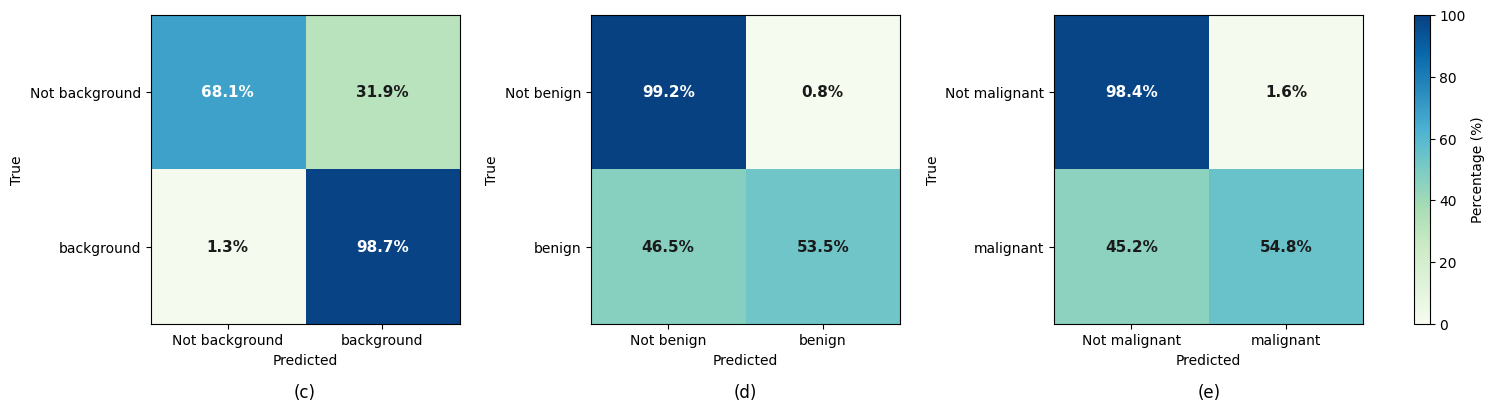

In [ ]:
# ===========================================================
# STEP 12: WD only – One-vs-Rest Confusion Matrices (Percentage)
# Styled to match your "light & beautiful" GnBu scheme
# ===========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_wd_ovr_confusion_matrices(y_true_onehot, y_pred_prob, class_names):
    # Flatten labels
    y_true = np.argmax(y_true_onehot, axis=-1).reshape(-1)
    y_pred = np.argmax(y_pred_prob, axis=-1).reshape(-1)

    n = len(class_names)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), constrained_layout=True)
    if n == 1:
        axes = [axes]

    panel_labels = ["(c)", "(d)", "(e)"]

    im = None
    for i, (ax, cls) in enumerate(zip(axes, class_names)):
        # One-vs-rest
        y_true_bin = (y_true == i).astype(int)
        y_pred_bin = (y_pred == i).astype(int)

        cm = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1]).astype(float)

        # Row-wise normalize to percentage, NaN-safe
        cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100.0
        cm_percent = np.nan_to_num(cm_percent, nan=0.0)

        # Heatmap with GnBu
        im = ax.imshow(cm_percent, cmap="GnBu", vmin=0, vmax=100)

        # Ticks and labels
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Not " + cls, cls])
        ax.set_yticklabels(["Not " + cls, cls])

        ax.set_xlabel("Predicted", fontsize=10)
        ax.set_ylabel("True", fontsize=10)

        # Cell annotations with adaptive text color
        for r in range(2):
            for c in range(2):
                value = cm_percent[r, c]
                txt_color = "white" if value > 60 else "#1a1a1a"
                ax.text(
                    c, r, f"{value:.1f}%",
                    ha="center", va="center",
                    color=txt_color,
                    fontsize=11,
                    fontweight="semibold"
                )

        # Panel label under each subplot
        if i < len(panel_labels):
            ax.text(
                0.5, -0.22, panel_labels[i],
                ha="center", va="center",
                transform=ax.transAxes,
                fontsize=12
            )

    # Shared colorbar
    cbar = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.04)
    cbar.set_label("Percentage (%)")

    # Make room for panel labels
    plt.subplots_adjust(bottom=0.22)

    plt.show()

# Example call (use your variables)
# y_pred_prob should be U_net_model.predict(Xte)
plot_wd_ovr_confusion_matrices(Yte, y_pred_prob, CLASS_NAMES)


20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 277ms/step


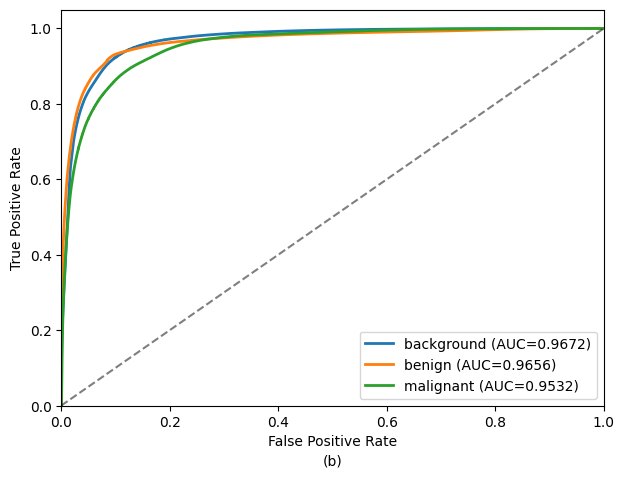


Per-class AUC:
background: 0.967164582344342
benign: 0.9656495982961484
malignant: 0.9532381818272979


In [ ]:
# ===========================================================
# STEP B: Plot Per-Class ROC-AUC Curves (One-vs-Rest)
# Needs:
#   Xte (or X_test)
#   Yte (one-hot) (or Y_test_onehot)
#   U_net_model
# ===========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Use your existing test variables
X_test = Xte
Y_test_onehot = Yte

class_names = ["background", "benign", "malignant"]

# 1) Predict probabilities
Y_pred_prob = model.predict(X_test, batch_size=8, verbose=1)  # (N,H,W,C)

# 2) Flatten true labels
Y_true_flat = np.argmax(Y_test_onehot, axis=-1).reshape(-1)

# 3) Compute ROC and AUC per class
fpr_dict, tpr_dict, auc_dict = {}, {}, {}

for i, cls in enumerate(class_names):
    y_true_bin = (Y_true_flat == i).astype(np.uint8)
    y_prob_cls = Y_pred_prob[..., i].reshape(-1)

    n_pos = int(y_true_bin.sum())
    n_neg = int(len(y_true_bin) - n_pos)

    if n_pos == 0 or n_neg == 0:
        fpr_dict[cls], tpr_dict[cls], auc_dict[cls] = None, None, np.nan
        print(f"Cannot compute ROC for '{cls}': positives={n_pos}, negatives={n_neg}")
        continue

    fpr, tpr, _ = roc_curve(y_true_bin, y_prob_cls)
    roc_auc = auc(fpr, tpr)

    fpr_dict[cls] = fpr
    tpr_dict[cls] = tpr
    auc_dict[cls] = roc_auc

# 4) Plot
plt.figure(figsize=(7, 6))

for cls in class_names:
    if fpr_dict[cls] is not None:
        plt.plot(
            fpr_dict[cls],
            tpr_dict[cls],
            linewidth=2,
            label=f"{cls} (AUC={auc_dict[cls]:.4f})"
        )

# Diagonal baseline
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="_nolegend_")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

# Panel label "(b)" below x-axis
ax = plt.gca()
plt.text(0.5, -0.14, "(b)", ha="center", va="center", transform=ax.transAxes)
plt.subplots_adjust(bottom=0.22)

plt.show()

# Optional: print AUCs
print("\nPer-class AUC:")
for cls in class_names:
    print(f"{cls}: {auc_dict[cls]}")


In [ ]:
# ===========================================================
# STEP 1: Mount Drive (do this first in a fresh runtime)
# ===========================================================

from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ===========================================================
# STEP 1: Search Google Drive for .keras models
# ===========================================================

import os

root = "/content/drive/MyDrive"

found = []
for r, d, files in os.walk(root):
    for f in files:
        if f.lower().endswith(".keras"):
            found.append(os.path.join(r, f))

print("Found .keras model files:")
for p in found:
    print(" -", p)

if len(found) == 0:
    print("❌ No .keras model found in your Drive.")

Found .keras model files:
 - /content/drive/MyDrive/Colab Notebooks/best_lstm_model.keras
 - /content/drive/MyDrive/Colab Notebooks/best_unet_model.keras
 - /content/drive/MyDrive/Colab Notebooks/best_trained_unet_model.keras
 - /content/drive/MyDrive/Colab Notebooks/BUSI_WD_ONLY/models/best_unet_tuned_model_WD.keras
 - /content/drive/MyDrive/Colab Notebooks/BUSI_WD_ONLY/models/unet_WD_final.keras


In [ ]:
# ===========================================================
# STEP: Load Saved WD U-Net Model (correct path)
# ===========================================================

from google.colab import drive
drive.mount("/content/drive")

from tensorflow.keras.models import load_model
import os

model_load_path = "/content/drive/MyDrive/Colab Notebooks/BUSI_WD_ONLY/models/best_unet_tuned_model_WD.keras"

print("Exists?", os.path.exists(model_load_path))
print("Path:", model_load_path)

U_net_model = load_model(model_load_path, compile=True)

print("✅ WD U-Net model loaded successfully!")
U_net_model.summary()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Exists? True
Path: /content/drive/MyDrive/Colab Notebooks/BUSI_WD_ONLY/models/best_unet_tuned_model_WD.keras


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 238 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✅ WD U-Net model loaded successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_3[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_4[0][0]  

 Total params: 150,728,651 (574.98 MB)

 Trainable params: 50,236,995 (191.64 MB)

 Non-trainable params: 17,664 (69.00 KB)

 Optimizer params: 100,473,992 (383.28 MB)

In [ ]:
# ===========================================================
# STEP 15: Generate Predicted Masks with Trained WD U-Net
# ===========================================================

import numpy as np

# Predict on training, validation, and test sets (WD variable names)
Ytr_pred = U_net_model.predict(Xtr, batch_size=8, verbose=1)
Yva_pred = U_net_model.predict(Xva, batch_size=8, verbose=1)
Yte_pred = U_net_model.predict(Xte, batch_size=8, verbose=1)

# Convert predicted probabilities to class labels
Ytr_pred_class = np.argmax(Ytr_pred, axis=-1)  # shape: (n_train, 256, 256)
Yva_pred_class = np.argmax(Yva_pred, axis=-1)  # shape: (n_val, 256, 256)
Yte_pred_class = np.argmax(Yte_pred, axis=-1)  # shape: (n_test, 256, 256)

# Quick sanity check
print("Train predictions shape:", Ytr_pred_class.shape)
print("Validation predictions shape:", Yva_pred_class.shape)
print("Test predictions shape:", Yte_pred_class.shape)


71/71 ━━━━━━━━━━━━━━━━━━━━ 26s 326ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 493ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 342ms/step
Train predictions shape: (561, 256, 256)
Validation predictions shape: (63, 256, 256)
Test predictions shape: (156, 256, 256)


In [ ]:
# ===========================================================
# STEP 16: Extract Morphology Features from WD U-Net Masks
# ===========================================================

import numpy as np
import pandas as pd
from skimage.measure import label, regionprops

def extract_morphology_features(images, masks):
    """
    images: (N, H, W, 1) grayscale images
    masks:  (N, H, W) predicted class masks with:
            0=background, 1=benign, 2=malignant
    returns: DataFrame with morphology features per sample
    """
    feature_list = []

    for i in range(len(images)):
        mask = masks[i]  # (H,W)

        # Tumor mask (ignore background)
        tumor_mask = (mask > 0).astype(np.uint8)

        # If no tumor detected
        if tumor_mask.sum() == 0:
            feature_list.append({
                "area": 0.0,
                "perimeter": 0.0,
                "circularity": 0.0,
                "solidity": 0.0,
                "centroid_x": np.nan,
                "centroid_y": np.nan
            })
            continue

        # Connected components
        labeled = label(tumor_mask)
        props = regionprops(labeled)

        if len(props) == 0:
            feature_list.append({
                "area": 0.0,
                "perimeter": 0.0,
                "circularity": 0.0,
                "solidity": 0.0,
                "centroid_x": np.nan,
                "centroid_y": np.nan
            })
            continue

        # Largest component
        r = max(props, key=lambda x: x.area)

        area = float(r.area)
        perimeter = float(r.perimeter)
        circularity = float(4.0 * np.pi * area / (perimeter**2 + 1e-6))
        solidity = float(r.solidity)

        cy, cx = r.centroid  # (row, col)

        feature_list.append({
            "area": area,
            "perimeter": perimeter,
            "circularity": circularity,
            "solidity": solidity,
            "centroid_x": float(cx),
            "centroid_y": float(cy)
        })

    return pd.DataFrame(feature_list)

# Extract features for WD splits (use WD variable names)
train_features = extract_morphology_features(Xtr, Ytr_pred_class)
val_features   = extract_morphology_features(Xva, Yva_pred_class)
test_features  = extract_morphology_features(Xte, Yte_pred_class)

# Quick check
print("Train features:", train_features.shape)
print("Val features  :", val_features.shape)
print("Test features :", test_features.shape)
print(train_features.head())


Train features: (561, 6)
Val features  : (63, 6)
Test features : (156, 6)
      area   perimeter   circularity  solidity  centroid_x  centroid_y
0   5431.0  431.333044  3.668295e-01  0.791345  112.906463   68.125944
1  11921.0  587.677236  4.337553e-01  0.917706   90.003355  130.594665
2   2576.0  354.747258  2.572276e-01  0.793348  115.460792   45.165373
3    566.0   96.183766  7.688166e-01  0.952862   92.220848   73.256184
4      1.0    0.000000  1.256637e+07  1.000000  112.000000   92.000000


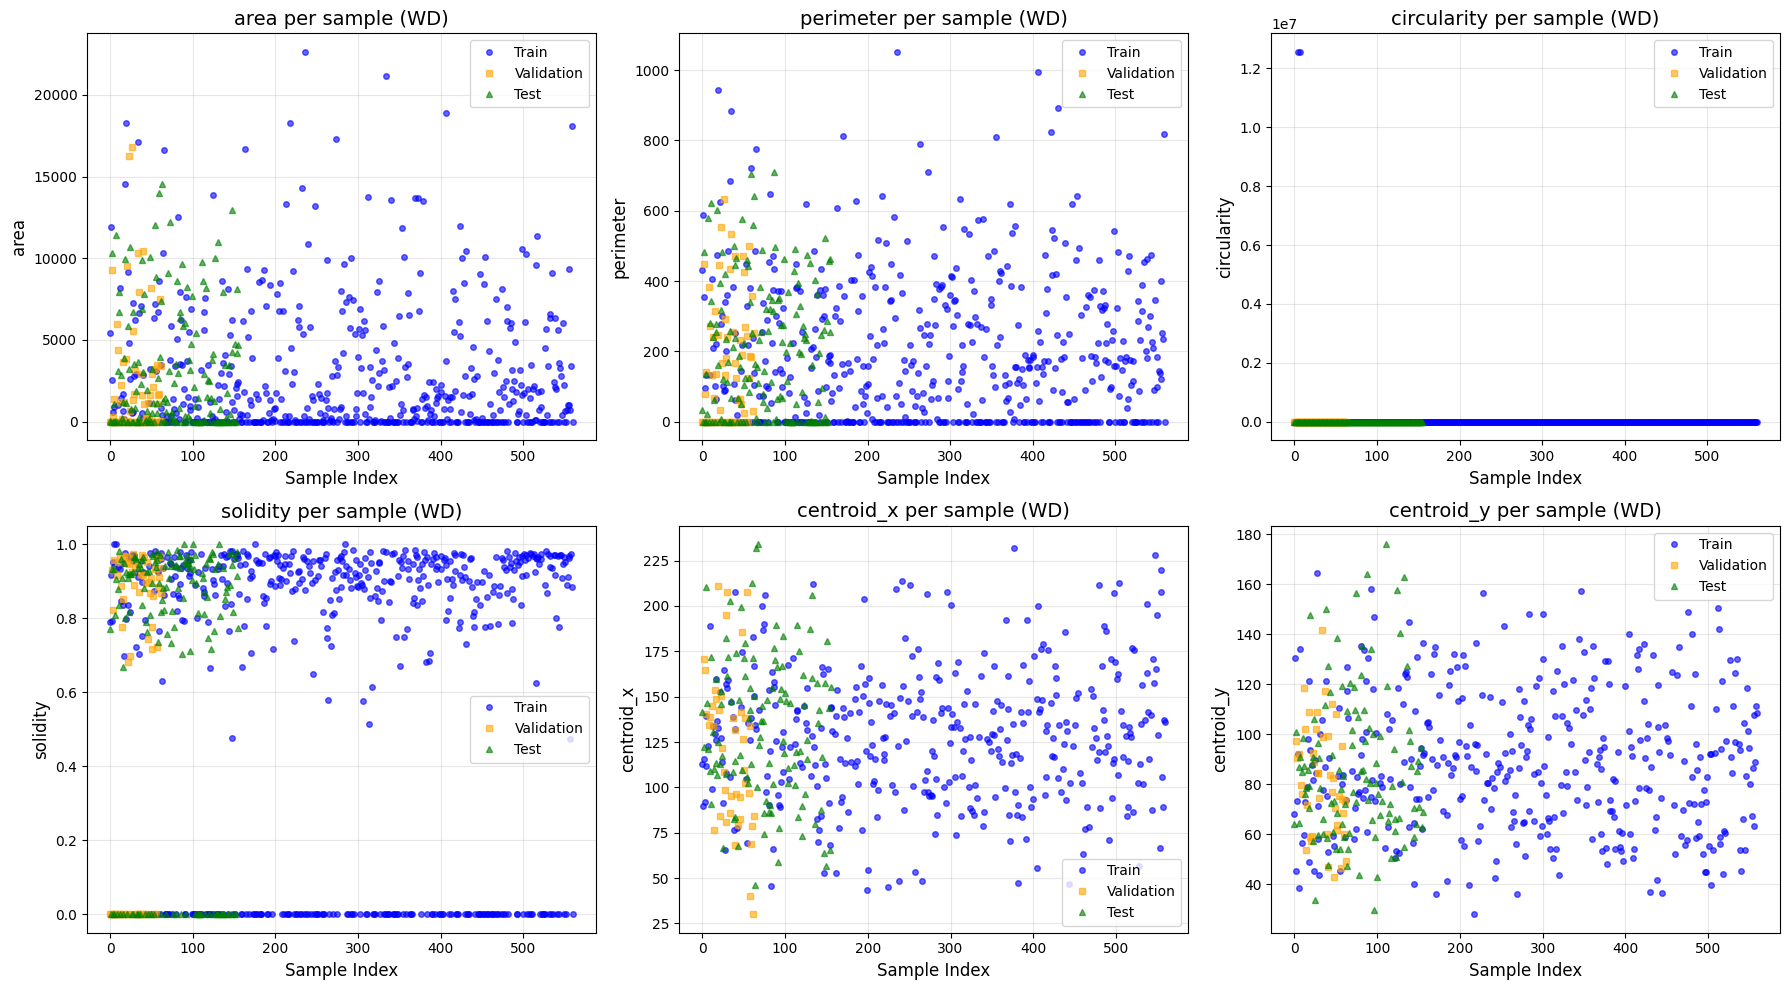

In [ ]:
# ===========================================================
# STEP 16c: Plot Morphology Feature Values per Sample (WD)
# ===========================================================

import matplotlib.pyplot as plt

features_to_plot = ['area', 'perimeter', 'circularity', 'solidity', 'centroid_x', 'centroid_y']

# Colors for each split
colors = {
    'Train': 'blue',
    'Val': 'orange',
    'Test': 'green'
}

plt.figure(figsize=(18, 10))

for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 3, i + 1)

    # Plot Train
    plt.plot(
        train_features[feature].values,
        marker='o', linestyle='', markersize=4,
        color=colors['Train'], alpha=0.6, label='Train'
    )

    # Plot Validation
    plt.plot(
        val_features[feature].values,
        marker='s', linestyle='', markersize=4,
        color=colors['Val'], alpha=0.6, label='Validation'
    )

    # Plot Test
    plt.plot(
        test_features[feature].values,
        marker='^', linestyle='', markersize=4,
        color=colors['Test'], alpha=0.6, label='Test'
    )

    plt.xlabel('Sample Index', fontsize=12)
    plt.ylabel(feature, fontsize=12)
    plt.title(f'{feature} per sample (WD)', fontsize=14)
    plt.legend()
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# ===========================================================
# STEP 1: Imports + sanity checks (WD morphology regression)
# Requires:
#   train_features, val_features, test_features
# from STEP 16 (morphology extraction)
# ===========================================================

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Morphology features we will use as inputs
feature_cols = ["area", "perimeter", "circularity", "solidity", "centroid_x", "centroid_y"]

for name, df in [("train_features", train_features), ("val_features", val_features), ("test_features", test_features)]:
    missing = [c for c in feature_cols if c not in df.columns]
    print(name, "shape:", df.shape, "missing:", missing)

print("✅ Ready for LSTM regression (WD).")


train_features shape: (561, 6) missing: []
val_features shape: (63, 6) missing: []
test_features shape: (156, 6) missing: []
✅ Ready for LSTM regression (WD).


In [ ]:
# ===========================================================
# STEP 2: Build X and Y for multi-target regression
# Targets: area, perimeter, circularity, solidity, centroid_x, centroid_y
# (You can change target_cols if needed)
# ===========================================================

target_cols = ["area", "perimeter", "circularity", "solidity", "centroid_x", "centroid_y"]

X_train_2d = train_features[feature_cols].values.astype(np.float64)
X_val_2d   = val_features[feature_cols].values.astype(np.float64)
X_test_2d  = test_features[feature_cols].values.astype(np.float64)

y_train_2d = train_features[target_cols].values.astype(np.float64)
y_val_2d   = val_features[target_cols].values.astype(np.float64)
y_test_2d  = test_features[target_cols].values.astype(np.float64)

print("X shapes:", X_train_2d.shape, X_val_2d.shape, X_test_2d.shape)
print("y shapes:", y_train_2d.shape, y_val_2d.shape, y_test_2d.shape)


X shapes: (561, 6) (63, 6) (156, 6)
y shapes: (561, 6) (63, 6) (156, 6)


In [ ]:
# ===========================================================
# STEP 3: Replace NaN/Inf in X and y with column medians
# ===========================================================

def replace_nan_inf_with_col_median(arr2d):
    arr2d = arr2d.copy()
    col_median = np.nanmedian(arr2d, axis=0)

    inds_nan = np.isnan(arr2d)
    inds_inf = np.isinf(arr2d)

    if inds_nan.any():
        arr2d[inds_nan] = np.take(col_median, np.where(inds_nan)[1])
    if inds_inf.any():
        arr2d[inds_inf] = np.take(col_median, np.where(inds_inf)[1])

    return arr2d

X_train_2d = replace_nan_inf_with_col_median(X_train_2d)
X_val_2d   = replace_nan_inf_with_col_median(X_val_2d)
X_test_2d  = replace_nan_inf_with_col_median(X_test_2d)

y_train_2d = replace_nan_inf_with_col_median(y_train_2d)
y_val_2d   = replace_nan_inf_with_col_median(y_val_2d)
y_test_2d  = replace_nan_inf_with_col_median(y_test_2d)

print("✅ NaN/Inf handled in X and y.")


✅ NaN/Inf handled in X and y.


In [ ]:
# ===========================================================
# STEP 4: Log1p transform selected targets (optional but helps)
# We'll log1p only on area and perimeter (usually large scale).
# Circularity/solidity are already in [0,1], centroids are moderate.
# ===========================================================

log_cols = ["area", "perimeter"]  # edit if you want

log_idx = [target_cols.index(c) for c in log_cols]

def apply_log1p_on_cols(y2d, idxs):
    y2d = y2d.copy()
    y2d[:, idxs] = np.log1p(np.maximum(y2d[:, idxs], 0.0))
    return y2d

y_train_log = apply_log1p_on_cols(y_train_2d, log_idx)
y_val_log   = apply_log1p_on_cols(y_val_2d, log_idx)
y_test_log  = apply_log1p_on_cols(y_test_2d, log_idx)

print("✅ Log1p applied to:", log_cols)


✅ Log1p applied to: ['area', 'perimeter']


In [ ]:
# ===========================================================
# STEP 5: Standardize X and y (fit on train only)
# ===========================================================

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_2d)
X_val_scaled   = scaler_X.transform(X_val_2d)
X_test_scaled  = scaler_X.transform(X_test_2d)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_log)
y_val_scaled   = scaler_y.transform(y_val_log)
y_test_scaled  = scaler_y.transform(y_test_log)

print("✅ Standardization done.")
print("X_train_scaled:", X_train_scaled.shape)
print("y_train_scaled:", y_train_scaled.shape)


✅ Standardization done.
X_train_scaled: (561, 6)
y_train_scaled: (561, 6)


In [ ]:
# ===========================================================
# STEP 6: Reshape for LSTM (timesteps=1)
# ===========================================================

X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_val_lstm   = X_val_scaled.reshape(X_val_scaled.shape[0], 1, X_val_scaled.shape[1])
X_test_lstm  = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

n_features = X_train_lstm.shape[2]
n_targets  = y_train_scaled.shape[1]

print("✅ LSTM input shape:", X_train_lstm.shape)
print("Targets:", n_targets, target_cols)


✅ LSTM input shape: (561, 1, 6)
Targets: 6 ['area', 'perimeter', 'circularity', 'solidity', 'centroid_x', 'centroid_y']


In [ ]:
# ===========================================================
# STEP 7: Build LSTM multi-target regression model
# ===========================================================

tf.keras.backend.clear_session()

inp = Input(shape=(1, n_features), name="morph_input")

x = LSTM(64, activation="tanh", return_sequences=False)(inp)
x = Dropout(0.3)(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.2)(x)

out = Dense(n_targets, activation="linear", name="morph_regression")(x)

lstm_reg_model = Model(inp, out)
lstm_reg_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=["mae", "mse"]
)

lstm_reg_model.summary()
print("✅ LSTM regression model compiled.")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ morph_input (InputLayer)        │ (None, 1, 6)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ morph_regression (Dense)        │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,726 (88.77 KB)

 Trainable params: 22,726 (88.77 KB)

 Non-trainable params: 0 (0.00 B)

✅ LSTM regression model compiled.


In [ ]:
# ===========================================================
# STEP 8: Train
# ===========================================================

callbacks = [
    EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6, verbose=1)
]

history = lstm_reg_model.fit(
    X_train_lstm, y_train_scaled,
    validation_data=(X_val_lstm, y_val_scaled),
    epochs=150,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

print("✅ LSTM regression trained.")


Epoch 1/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 1.1681 - mae: 0.6796 - mse: 1.1681 - val_loss: 0.5528 - val_mae: 0.5776 - val_mse: 0.5528 - learning_rate: 0.0010
Epoch 2/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.6291 - mae: 0.5186 - mse: 0.6291 - val_loss: 0.2139 - val_mae: 0.3204 - val_mse: 0.2139 - learning_rate: 0.0010
Epoch 3/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.5007 - mae: 0.3260 - mse: 0.5007 - val_loss: 0.0817 - val_mae: 0.1735 - val_mse: 0.0817 - learning_rate: 0.0010
Epoch 4/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1798 - mae: 0.2267 - mse: 0.1798 - val_loss: 0.0364 - val_mae: 0.1362 - val_mse: 0.0364 - learning_rate: 0.0010
Epoch 5/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1243 - mae: 0.2022 - mse: 0.1243 - val_loss: 0.0217 - val_mae: 0.1068 - val_mse: 0.0217 - learning_rate: 0.0010
Epoch 6/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0778 - mae: 0.1882 - mse: 0.0778 - val_loss: 0.0180 - val_mae: 0.097

In [ ]:
# ===========================================================
# STEP 9: Predict + inverse transform back to original scale
# ===========================================================

y_pred_scaled = lstm_reg_model.predict(X_test_lstm, verbose=0)

# Inverse standardization
y_pred_log = scaler_y.inverse_transform(y_pred_scaled)
y_true_log = scaler_y.inverse_transform(y_test_scaled)

# Undo log1p for selected columns
def undo_log1p_on_cols(y2d, idxs):
    y2d = y2d.copy()
    y2d[:, idxs] = np.expm1(y2d[:, idxs])
    return y2d

y_pred = undo_log1p_on_cols(y_pred_log, log_idx)
y_true = undo_log1p_on_cols(y_true_log, log_idx)

print("✅ Predictions transformed back to original scale.")
print("y_pred shape:", y_pred.shape)


✅ Predictions transformed back to original scale.
y_pred shape: (156, 6)


In [ ]:
# ===========================================================
# STEP 10: Print regression results per target (MAE, MSE, RMSE, R2)
# ===========================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

results = []

for j, col in enumerate(target_cols):
    yt = y_true[:, j]
    yp = y_pred[:, j]

    mae = mean_absolute_error(yt, yp)
    mse = mean_squared_error(yt, yp)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(yt, yp)

    results.append([col, mae, mse, rmse, r2])

results_df = pd.DataFrame(results, columns=["target", "MAE", "MSE", "RMSE", "R2"])
print(results_df.to_string(index=False))

print("\n✅ First 10 predictions (per target):")
for j, col in enumerate(target_cols):
    print(col, "pred:", np.round(y_pred[:10, j], 4), "true:", np.round(y_true[:10, j], 4))


     target          MAE          MSE         RMSE            R2
       area   573.316634 1.176813e+06  1084.810046  9.149142e-01
  perimeter    22.004986 1.283558e+03    35.826774  9.643048e-01
circularity 12245.676943 2.513861e+08 15855.158607 -1.421734e+07
   solidity     0.027748 1.386689e-03     0.037238  9.916269e-01
 centroid_x     2.585963 1.400055e+01     3.741731  9.878476e-01
 centroid_y     2.685040 1.352693e+01     3.677898  9.787988e-01

✅ First 10 predictions (per target):
area pred: [1.4233929e+02 9.4499998e-02 8.9073535e+03 9.4499998e-02 9.4499998e-02
 7.4254779e+02 1.5970380e+02 1.0156197e+04 9.4499998e-02 2.8748367e+03] true: [   54.     0. 10343.     0.     0.  1066.    34. 11440.     0.  3095.]
perimeter pred: [3.432160e+01 8.470000e-02 4.801752e+02 8.470000e-02 8.470000e-02
 1.086737e+02 3.740840e+01 5.466440e+02 8.470000e-02 2.507451e+02] true: [ 32.0416   0.     481.5879   0.       0.     135.1543  22.8995 578.2925
   0.     280.2559]
circularity pred: [ -7042.1

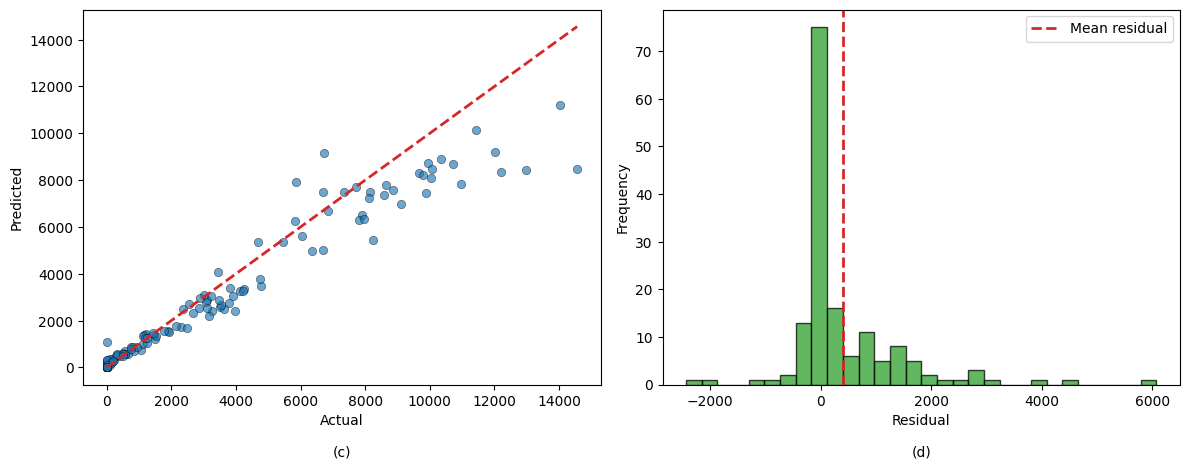

In [ ]:
# ===========================================================
# STEP 11: Optional plots (Actual vs Predicted + Residuals) for ONE target
# Choose a target to visualise (default: area)
# ===========================================================

import matplotlib.pyplot as plt

target_to_plot = "area"  # change if you want
j = target_cols.index(target_to_plot)

yt = y_true[:, j]
yp = y_pred[:, j]
residuals = yt - yp

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1) Actual vs Predicted
axes[0].scatter(
    yt, yp,
    color="tab:blue",
    alpha=0.65,
    edgecolors="k",
    linewidths=0.4
)

mn = float(min(yt.min(), yp.min()))
mx = float(max(yt.max(), yp.max()))

axes[0].plot(
    [mn, mx], [mn, mx],
    color="tab:red",
    linestyle="--",
    linewidth=2
)

axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].grid(False)

# 2) Residuals distribution
axes[1].hist(
    residuals,
    bins=30,
    color="tab:green",
    alpha=0.75,
    edgecolor="black"
)

axes[1].axvline(
    residuals.mean(),
    color="tab:red",
    linestyle="--",
    linewidth=2,
    label="Mean residual"
)

axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].grid(False)

# Adjust layout to make room for labels
plt.tight_layout()
plt.subplots_adjust(bottom=0.22)

# Add panel labels under each subplot
axes[0].text(
    0.5, -0.18, "(c)",
    ha="center", va="center",
    transform=axes[0].transAxes
)

axes[1].text(
    0.5, -0.18, "(d)",
    ha="center", va="center",
    transform=axes[1].transAxes
)

plt.show()


In [ ]:
import numpy as np
import pandas as pd

# Choose target
target_name = "area"
j = target_cols.index(target_name)

y_true_cont = y_true[:, j]
y_pred_cont = y_pred[:, j]

# Define tolerance (e.g., 10% of true value or fixed value)
tol = 0.1 * np.mean(y_true_cont)  # you can change this

# Build categories: -1 = under, 0 = ok, +1 = over
diff = y_pred_cont - y_true_cont

y_err_class = np.zeros_like(diff, dtype=int)
y_err_class[diff < -tol] = -1   # under-estimate
y_err_class[diff >  tol] =  1   # over-estimate

# Count results
labels = ["Under", "OK", "Over"]
counts = pd.Series(y_err_class).value_counts().sort_index()

print("Error category counts for", target_name)
for k, name in zip([-1, 0, 1], labels):
    print(f"{name:5s}:", counts.get(k, 0))


Error category counts for area
Under: 53
OK   : 94
Over : 9


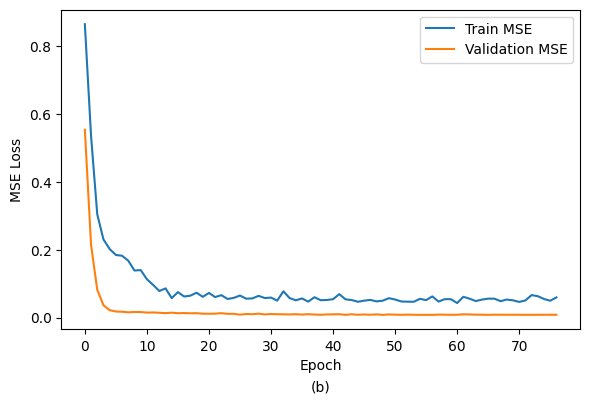

In [ ]:
# -----------------------------
# Regression Training Loss (MSE)
# -----------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

# Plot training and validation loss
plt.plot(history.history['loss'], label='Train MSE')
plt.plot(history.history['val_loss'], label='Validation MSE')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
# plt.title('LSTM Regression Training Loss (WD)')
plt.legend()
plt.grid(False)

# Add panel label "(b)" below the x-axis label
ax = plt.gca()
plt.text(
    0.5, -0.18, "(b)",
    ha="center", va="center",
    transform=ax.transAxes
)

# Make room at the bottom for "(b)"
plt.subplots_adjust(bottom=0.28)

plt.tight_layout()
plt.show()


In [ ]:
# ===========================================================
# STEP: Print MSE, MAE, RMSE for WD LSTM Regression
# ===========================================================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Overall metrics (averaged over all targets and samples)
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

print("📊 Regression Performance (WD, all targets combined):")
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")


📊 Regression Performance (WD, all targets combined):
MAE : 2141.0496
MSE : 42094029.7291
RMSE: 6487.9912


In [ ]:
# ===========================================================
# STEP: Print Percentage Errors for WD LSTM Regression
# ===========================================================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

eps = 1e-8  # to avoid division by zero

# Percentage errors
mape = np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100.0
rmspe = np.sqrt(np.mean(((y_true - y_pred) / (y_true + eps))**2)) * 100.0

# Also keep raw MAE/MSE/RMSE for reference
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

print("📊 Regression Performance (WD):")
print(f"MAE   : {mae:.4f}")
print(f"MSE   : {mse:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"MAPE  : {mape:.2f}%")
print(f"RMSPE : {rmspe:.2f}%")


📊 Regression Performance (WD):
MAE   : 2141.0496
MSE   : 42094029.7291
RMSE  : 6487.9912
MAPE  : 2635006408455.30%
RMSPE : 12293369975575.93%


In [ ]:
# ===========================================================
# STEP: Print Percentage Errors for WD LSTM Regression
# ===========================================================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

eps = 1e-8  # to avoid division by zero

# Percentage errors
mape = np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100.0
rmspe = np.sqrt(np.mean(((y_true - y_pred) / (y_true + eps))**2)) * 100.0

# Raw regression metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("📊 Regression Performance (WD):")
print(f"MAE   : {mae:.4f}")
print(f"MSE   : {mse:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"R²    : {r2:.4f}")
print(f"MAPE  : {mape:.2f}%")
print(f"RMSPE : {rmspe:.2f}%")


📊 Regression Performance (WD):
MAE   : 2141.0496
MSE   : 42094029.7291
RMSE  : 6487.9912
R²    : -2369555.5419
MAPE  : 2635006408455.30%
RMSPE : 12293369975575.93%


In [ ]:
# ===========================================================
# STEP: Per-target MSE, MAE, RMSE
# ===========================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

rows = []

for j, col in enumerate(target_cols):
    yt = y_true[:, j]
    yp = y_pred[:, j]

    mae_j = mean_absolute_error(yt, yp)
    mse_j = mean_squared_error(yt, yp)
    rmse_j = np.sqrt(mse_j)

    rows.append([col, mae_j, mse_j, rmse_j])

metrics_df = pd.DataFrame(rows, columns=["Feature", "MAE", "MSE", "RMSE"])
print("\n📊 Per-feature Regression Performance (WD):")
print(metrics_df.to_string(index=False))



📊 Per-feature Regression Performance (WD):
    Feature          MAE          MSE         RMSE
       area   573.316634 1.176813e+06  1084.810046
  perimeter    22.004986 1.283558e+03    35.826774
circularity 12245.676943 2.513861e+08 15855.158607
   solidity     0.027748 1.386689e-03     0.037238
 centroid_x     2.585963 1.400055e+01     3.741731
 centroid_y     2.685040 1.352693e+01     3.677898
